In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

SEED = 42
np.random.seed(SEED)

## 1. Load Training Data and Check Class Distribution

In [2]:
# Load training data
train_df = pd.read_csv('../data/preprocessed/train.csv')

# Target variable
TARGET = 'Scope_3_coverage'

# Check class distribution
class_counts = train_df[TARGET].value_counts()
class_proportions = train_df[TARGET].value_counts(normalize=True) * 100

print("=" * 50)
print("CLASS DISTRIBUTION (Training Set)")
print("=" * 50)
print(f"\nTotal samples: {len(train_df)}\n")

for cls in class_counts.index:
    count = class_counts[cls]
    pct = class_proportions[cls]
    print(f"{cls:20s}: {count:5d} samples ({pct:5.1f}%)")

print(f"\nMinority class: {class_counts.idxmin()} ({class_proportions.min():.1f}%)")
print(f"Majority class: {class_counts.idxmax()} ({class_proportions.max():.1f}%)")
print(f"Imbalance ratio: {class_counts.max() / class_counts.min():.2f}:1")

CLASS DISTRIBUTION (Training Set)

Total samples: 1131

Yes                 :   456 samples ( 40.3%)
Not Specified       :   247 samples ( 21.8%)
Partial             :   220 samples ( 19.5%)
No                  :   208 samples ( 18.4%)

Minority class: No (18.4%)
Majority class: Yes (40.3%)
Imbalance ratio: 2.19:1


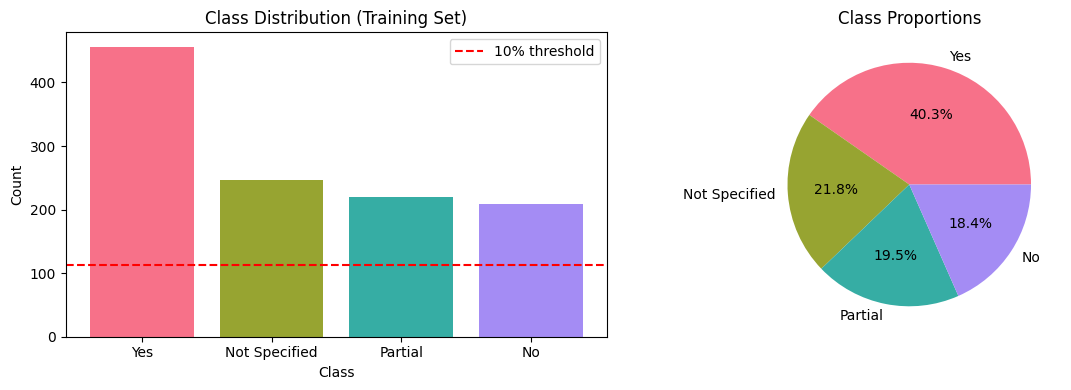

In [3]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = sns.color_palette('husl', n_colors=len(class_counts))
axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Training Set)')
axes[0].axhline(y=len(train_df)*0.10, color='red', linestyle='--', label='10% threshold')
axes[0].legend()

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

## 2. Decision: Is SMOTE Needed?

**Rule:** Apply SMOTE if minority class < 10%

In [4]:
# Check if SMOTE is needed
minority_pct = class_proportions.min()
SMOTE_THRESHOLD = 10.0  # 10%

print("=" * 50)
print("SMOTE DECISION")
print("=" * 50)
print(f"\nMinority class proportion: {minority_pct:.1f}%")
print(f"SMOTE threshold: {SMOTE_THRESHOLD}%")

if minority_pct < SMOTE_THRESHOLD:
    print(f"\n✅ SMOTE RECOMMENDED: Minority class ({minority_pct:.1f}%) is below {SMOTE_THRESHOLD}% threshold")
    APPLY_SMOTE = True
else:
    print(f"\n⚠️ SMOTE NOT STRICTLY NEEDED: Minority class ({minority_pct:.1f}%) is above {SMOTE_THRESHOLD}% threshold")
    print("   However, with 4 classes, we may still benefit from balancing.")
    APPLY_SMOTE = True  # Still apply for multi-class scenario

SMOTE DECISION

Minority class proportion: 18.4%
SMOTE threshold: 10.0%

⚠️ SMOTE NOT STRICTLY NEEDED: Minority class (18.4%) is above 10.0% threshold
   However, with 4 classes, we may still benefit from balancing.


## 3. Prepare Features and Target

In [5]:
# Features to drop (leakage + target)
LEAKAGE_COLS = ['Scope_1_coverage', 'Scope_2_coverage']
DROP_COLS = [TARGET] + [col for col in LEAKAGE_COLS if col in train_df.columns]

# Separate features and target
X_train = train_df.drop(columns=DROP_COLS, errors='ignore')
y_train = train_df[TARGET]

print(f"Features shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")
print(f"\nFeature columns: {list(X_train.columns)}")

Features shape: (1131, 20)
Target shape: (1131,)

Feature columns: ['Country', 'Geographic_region', 'Private_company', 'End_target', 'End_target_year', 'Status_of_end_target', 'Interim_target', 'Interim_target_year', 'GHGs_covered', 'Published_plan', 'Reporting_mechanism', 'Accountability_delivery', 'Carbon_credits', 'Separate_removal_target', 'Planning_removals', 'Historical_emissions', 'Race_to_zero_member', 'Industry', 'log_revenue', 'log_employees']


In [6]:
# Check data types - SMOTE works best with numeric data
print("Data types:")
print(X_train.dtypes.value_counts())

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")

Data types:
object     16
float64     4
Name: count, dtype: int64

Categorical columns (16): ['Country', 'Geographic_region', 'Private_company', 'End_target', 'Status_of_end_target', 'Interim_target', 'GHGs_covered', 'Published_plan', 'Reporting_mechanism', 'Accountability_delivery', 'Carbon_credits', 'Separate_removal_target', 'Planning_removals', 'Historical_emissions', 'Race_to_zero_member', 'Industry']
Numeric columns (4): ['End_target_year', 'Interim_target_year', 'log_revenue', 'log_employees']


## 4. Encode Categorical Features for SMOTE

⚠️ **Important:** SMOTE requires numeric features. We need to encode categorical variables first.

In [7]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

# Get actual columns from data
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

# Split categorical into high/low cardinality for encoding
NOMINAL_HIGH_CARD = ['Country', 'Industry']  # OneHot these
ordinal_cols = [c for c in categorical_cols if c not in NOMINAL_HIGH_CARD]  # OrdinalEncode rest
nominal_cols = [c for c in NOMINAL_HIGH_CARD if c in categorical_cols]

print(f"Ordinal columns ({len(ordinal_cols)}): {ordinal_cols}")
print(f"Nominal columns ({len(nominal_cols)}): {nominal_cols}")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")

Ordinal columns (14): ['Geographic_region', 'Private_company', 'End_target', 'Status_of_end_target', 'Interim_target', 'GHGs_covered', 'Published_plan', 'Reporting_mechanism', 'Accountability_delivery', 'Carbon_credits', 'Separate_removal_target', 'Planning_removals', 'Historical_emissions', 'Race_to_zero_member']
Nominal columns (2): ['Country', 'Industry']
Numeric columns (4): ['End_target_year', 'Interim_target_year', 'log_revenue', 'log_employees']


In [8]:
# Create preprocessing pipeline for SMOTE
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
        ('nominal', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), nominal_cols),
        ('numeric', StandardScaler(), numeric_cols)
    ],
    remainder='drop'
)

# Fit and transform training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Encode target
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

print(f"Encoded features shape: {X_train_encoded.shape}")
print(f"Target classes: {label_encoder.classes_}")

Encoded features shape: (1131, 85)
Target classes: ['No' 'Not Specified' 'Partial' 'Yes']


## 5. Apply SMOTE

In [9]:
# Import imblearn
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
print("✅ imblearn imported successfully")

✅ imblearn imported successfully


In [10]:
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Record before counts
before_counts = Counter(y_train_encoded)
print("BEFORE SMOTE:")
for cls_idx, count in sorted(before_counts.items()):
    cls_name = label_encoder.classes_[cls_idx]
    print(f"  {cls_name}: {count}")
print(f"  Total: {sum(before_counts.values())}")

BEFORE SMOTE:
  No: 208
  Not Specified: 247
  Partial: 220
  Yes: 456
  Total: 1131


In [11]:
# Apply SMOTE
# Using k_neighbors=5 (default), but reduce if minority class is too small
min_samples = min(before_counts.values())
k_neighbors = min(5, min_samples - 1)

smote = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train_encoded)

# Record after counts
after_counts = Counter(y_train_resampled)
print("AFTER SMOTE:")
for cls_idx, count in sorted(after_counts.items()):
    cls_name = label_encoder.classes_[cls_idx]
    change = count - before_counts[cls_idx]
    print(f"  {cls_name}: {count} (+{change} synthetic)")
print(f"  Total: {sum(after_counts.values())}")

logging.info(f"SMOTE applied: {sum(before_counts.values())} -> {sum(after_counts.values())} samples")

2025-12-20 14:27:16,158 - INFO - SMOTE applied: 1131 -> 1824 samples


AFTER SMOTE:
  No: 456 (+248 synthetic)
  Not Specified: 456 (+209 synthetic)
  Partial: 456 (+236 synthetic)
  Yes: 456 (+0 synthetic)
  Total: 1824


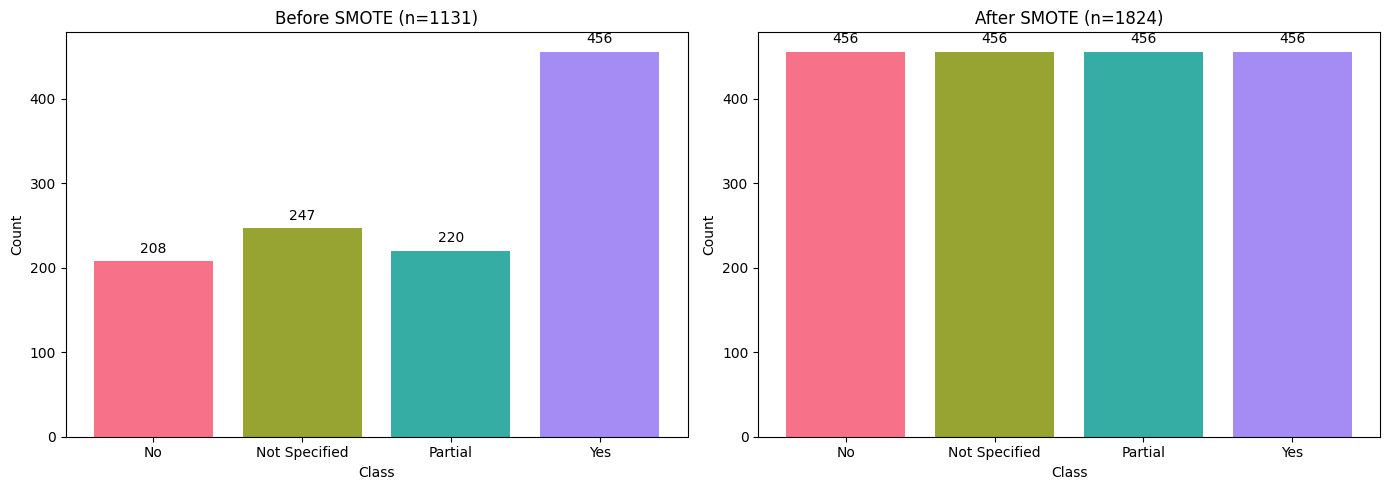

In [12]:
# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
before_labels = [label_encoder.classes_[i] for i in sorted(before_counts.keys())]
before_values = [before_counts[i] for i in sorted(before_counts.keys())]
axes[0].bar(before_labels, before_values, color=colors)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Before SMOTE (n={sum(before_values)})')
for i, v in enumerate(before_values):
    axes[0].text(i, v + 10, str(v), ha='center')

# After SMOTE
after_labels = [label_encoder.classes_[i] for i in sorted(after_counts.keys())]
after_values = [after_counts[i] for i in sorted(after_counts.keys())]
axes[1].bar(after_labels, after_values, color=colors)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_title(f'After SMOTE (n={sum(after_values)})')
for i, v in enumerate(after_values):
    axes[1].text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()

## 6. (Optional) SMOTE + Tomek Links

SMOTETomek combines oversampling with cleaning by removing Tomek links (ambiguous boundary samples).

In [13]:
# Apply SMOTETomek for cleaner boundaries
smote_tomek = SMOTETomek(random_state=SEED)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train_encoded, y_train_encoded)

st_counts = Counter(y_train_st)
print("AFTER SMOTETomek:")
for cls_idx, count in sorted(st_counts.items()):
    cls_name = label_encoder.classes_[cls_idx]
    print(f"  {cls_name}: {count}")
print(f"  Total: {sum(st_counts.values())}")

logging.info(f"SMOTETomek: Removed {sum(after_counts.values()) - sum(st_counts.values())} Tomek links")

2025-12-20 14:27:30,400 - INFO - SMOTETomek: Removed 56 Tomek links


AFTER SMOTETomek:
  No: 443
  Not Specified: 444
  Partial: 446
  Yes: 435
  Total: 1768


## 7. Compare Model Performance: Original vs SMOTE

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score

# Load and prepare validation data
val_df = pd.read_csv('../data/preprocessed/val.csv')
X_val = val_df.drop(columns=DROP_COLS, errors='ignore')
y_val = val_df[TARGET]

# Encode validation data (using same preprocessor fitted on training)
X_val_encoded = preprocessor.transform(X_val)
y_val_encoded = label_encoder.transform(y_val)

print(f"Validation set: {X_val_encoded.shape[0]} samples (original distribution)")

Validation set: 377 samples (original distribution)


In [15]:
# Train model on ORIGINAL data
rf_original = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_original.fit(X_train_encoded, y_train_encoded)
y_pred_original = rf_original.predict(X_val_encoded)

print("=" * 60)
print("MODEL TRAINED ON ORIGINAL DATA")
print("=" * 60)
print(f"\nBalanced Accuracy: {balanced_accuracy_score(y_val_encoded, y_pred_original):.3f}")
print("\nClassification Report:")
print(classification_report(y_val_encoded, y_pred_original, 
                            target_names=label_encoder.classes_))

MODEL TRAINED ON ORIGINAL DATA

Balanced Accuracy: 0.466

Classification Report:
               precision    recall  f1-score   support

           No       0.49      0.36      0.41        70
Not Specified       0.60      0.63      0.62        82
      Partial       0.25      0.08      0.12        73
          Yes       0.56      0.79      0.65       152

     accuracy                           0.54       377
    macro avg       0.48      0.47      0.45       377
 weighted avg       0.49      0.54      0.50       377



In [16]:
# Train model on SMOTE-resampled data
rf_smote = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_smote.fit(X_train_resampled, y_train_resampled)
y_pred_smote = rf_smote.predict(X_val_encoded)

print("=" * 60)
print("MODEL TRAINED ON SMOTE DATA")
print("=" * 60)
print(f"\nBalanced Accuracy: {balanced_accuracy_score(y_val_encoded, y_pred_smote):.3f}")
print("\nClassification Report:")
print(classification_report(y_val_encoded, y_pred_smote, 
                            target_names=label_encoder.classes_))

MODEL TRAINED ON SMOTE DATA

Balanced Accuracy: 0.448

Classification Report:
               precision    recall  f1-score   support

           No       0.44      0.40      0.42        70
Not Specified       0.60      0.60      0.60        82
      Partial       0.16      0.08      0.11        73
          Yes       0.56      0.71      0.62       152

     accuracy                           0.51       377
    macro avg       0.44      0.45      0.44       377
 weighted avg       0.47      0.51      0.48       377



In [17]:
# Train model on SMOTETomek data
rf_st = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_st.fit(X_train_st, y_train_st)
y_pred_st = rf_st.predict(X_val_encoded)

print("=" * 60)
print("MODEL TRAINED ON SMOTETomek DATA")
print("=" * 60)
print(f"\nBalanced Accuracy: {balanced_accuracy_score(y_val_encoded, y_pred_st):.3f}")
print("\nClassification Report:")
print(classification_report(y_val_encoded, y_pred_st, 
                            target_names=label_encoder.classes_))

MODEL TRAINED ON SMOTETomek DATA

Balanced Accuracy: 0.442

Classification Report:
               precision    recall  f1-score   support

           No       0.43      0.37      0.40        70
Not Specified       0.61      0.60      0.60        82
      Partial       0.17      0.11      0.13        73
          Yes       0.55      0.69      0.61       152

     accuracy                           0.50       377
    macro avg       0.44      0.44      0.44       377
 weighted avg       0.47      0.50      0.48       377



## 8. Summary & Documentation

In [18]:
# Summary comparison
print("=" * 70)
print("RESAMPLING COMPARISON SUMMARY")
print("=" * 70)

results = {
    'Original': {
        'samples': sum(before_counts.values()),
        'balanced_acc': balanced_accuracy_score(y_val_encoded, y_pred_original)
    },
    'SMOTE': {
        'samples': sum(after_counts.values()),
        'balanced_acc': balanced_accuracy_score(y_val_encoded, y_pred_smote)
    },
    'SMOTETomek': {
        'samples': sum(st_counts.values()),
        'balanced_acc': balanced_accuracy_score(y_val_encoded, y_pred_st)
    }
}

print(f"\n{'Method':<15} {'Samples':>10} {'Balanced Acc':>15}")
print("-" * 42)
for method, metrics in results.items():
    print(f"{method:<15} {metrics['samples']:>10} {metrics['balanced_acc']:>15.3f}")

# Best method
best_method = max(results.keys(), key=lambda k: results[k]['balanced_acc'])
print(f"\n✅ Best performing method: {best_method}")

RESAMPLING COMPARISON SUMMARY

Method             Samples    Balanced Acc
------------------------------------------
Original              1131           0.466
SMOTE                 1824           0.448
SMOTETomek            1768           0.442

✅ Best performing method: Original


In [19]:
# Document resampling decision
print("\n" + "=" * 70)
print("RESAMPLING DECISION DOCUMENTATION")
print("=" * 70)
print(f"""
Dataset: Net Zero Tracker - Scope_3_coverage Classification
Date: 2025-12-20

CLASS DISTRIBUTION (Before Resampling):
""")
for cls_idx, count in sorted(before_counts.items()):
    cls_name = label_encoder.classes_[cls_idx]
    pct = count / sum(before_counts.values()) * 100
    print(f"  - {cls_name}: {count} ({pct:.1f}%)")

print(f"""
SMOTE THRESHOLD: 10%
MINORITY CLASS: {label_encoder.classes_[min(before_counts, key=before_counts.get)]} ({min(before_counts.values()) / sum(before_counts.values()) * 100:.1f}%)

DECISION: {'Applied SMOTE' if APPLY_SMOTE else 'No resampling needed'}
RATIONALE: {'Multi-class imbalance benefits from balanced training' if APPLY_SMOTE else 'Minority class above 10% threshold'}

RESAMPLING RESULTS:
  - Original: {sum(before_counts.values())} samples
  - After SMOTE: {sum(after_counts.values())} samples
  - After SMOTETomek: {sum(st_counts.values())} samples

RECOMMENDATION: Use {best_method} for training (Balanced Acc: {results[best_method]['balanced_acc']:.3f})
""")


RESAMPLING DECISION DOCUMENTATION

Dataset: Net Zero Tracker - Scope_3_coverage Classification
Date: 2025-12-20

CLASS DISTRIBUTION (Before Resampling):

  - No: 208 (18.4%)
  - Not Specified: 247 (21.8%)
  - Partial: 220 (19.5%)
  - Yes: 456 (40.3%)

SMOTE THRESHOLD: 10%
MINORITY CLASS: No (18.4%)

DECISION: Applied SMOTE
RATIONALE: Multi-class imbalance benefits from balanced training

RESAMPLING RESULTS:
  - Original: 1131 samples
  - After SMOTE: 1824 samples
  - After SMOTETomek: 1768 samples

RECOMMENDATION: Use Original for training (Balanced Acc: 0.466)



## 9. Save Resampled Data (Optional)

In [20]:
import joblib
import os

# Create models directory if needed
os.makedirs('../models', exist_ok=True)

# Save the best resampled data and artifacts
artifacts = {
    'X_train_original': X_train_encoded,
    'y_train_original': y_train_encoded,
    'X_train_smote': X_train_resampled,
    'y_train_smote': y_train_resampled,
    'X_train_smotetomek': X_train_st,
    'y_train_smotetomek': y_train_st,
    'preprocessor': preprocessor,
    'label_encoder': label_encoder,
    'class_counts_before': dict(before_counts),
    'class_counts_after_smote': dict(after_counts),
    'class_counts_after_st': dict(st_counts)
}

joblib.dump(artifacts, '../models/smote_artifacts.pkl')
print("✅ SMOTE artifacts saved to ../models/smote_artifacts.pkl")

✅ SMOTE artifacts saved to ../models/smote_artifacts.pkl
